# Week 4 — Embeddings, Similarity & Modalities
### *Understanding How Meaning Becomes Geometry*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/embeddings_lecture.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

---

### 🎯 Learning Objectives
By the end of this week, you should be able to:
- Explain what an **embedding** is and how it represents meaning numerically.
- Compute and interpret **cosine similarity** between vectors.
- Describe (at a high level) **how embeddings are learned** from data.
- Understand **semantic search** conceptually *and* mathematically.
- Visualize embedding clusters and reason about **multimodal representations**.

> **Big idea:** embeddings let us treat “meaning” like **geometry** — and then we can do math on it.


In [1]:
# @title Setup (Run this first)
!git clone  --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append('/content/main')
from course_utils import lab4_setup, show_mermaid
lab4_setup()
print("✅ Environment ready!")

🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Installing additional packages: scikit-learn
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab4_setup complete — ready.
✅ Environment ready!


In [2]:
# @title Imports + helper functions (Run after setup)
from openai import OpenAI
import numpy as np
import matplotlib.pyplot as plt

client = OpenAI()
# https://platform.openai.com/docs/models/text-embedding-3-small
EMBEDDING_MODEL = "text-embedding-3-small"

def get_embedding(text: str) -> np.ndarray:
    """Return a 1D numpy array embedding for `text`."""
    # IMPORTANT: this is the key API call we'll use all week
    emb = client.embeddings.create(input=text, model=EMBEDDING_MODEL).data[0].embedding
    return np.array(emb, dtype=np.float32)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity in [-1, 1]. 1 = same direction."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

print("✅ Imports ready. (If you get an auth error, make sure your OpenAI key is set.)")


✅ Imports ready. (If you get an auth error, make sure your OpenAI key is set.)


# 🧭 Day 1 — Geometry of Meaning

**Warm‑up (5–10 min): What did we build last week?**
- In pairs: What was the *input*, *model*, and *output* of last week’s lab?
- Where did your system *struggle*? Where did it *surprise you*?

We’re going to add a new ingredient to our toolbox: **embeddings**.

---

## **Guiding questions for today**
- **What is an embedding, and why does it help us compare meaning?**
- **What does cosine similarity measure, and why does it show up everywhere?**
- **What kinds of mistakes do similarity methods make?**


## 🌟 Motivating Example — Why “cardiac doctor” should match “cardiologist”

**Imagine you’re searching a hospital knowledge base.**

- ✅ **Keyword search** works great when the exact word appears.
- ❌ But it fails when people use **synonyms**, **paraphrases**, or **different phrasing**.

**Try to predict before running the cell:**
- If the query is **“cardiac doctor”**, which document *should* be ranked highest?
- Which method (keyword vs semantic) do you expect to do better?

We’ll compare:
1. A simple keyword baseline
2. Semantic search using **OpenAI embeddings**


In [3]:
# @title Keyword vs Embedding Similarity (Semantic Search) — quick demo
docs = [
    "A cardiologist specializes in heart conditions.",
    "A dermatologist is a doctor that treats diseases of the skin.",
    "A mechanic repairs car engines and brakes.",
    "Heart attacks can be prevented with healthy habits.",
    "A cardiac doctor specializes in heart conditions.",
]
query = "cardiac doctor"

# --- Keyword baseline (very naive) ---
query_words = set(query.lower().split())
keyword_scores = []
for d in docs:
    d_words = set(d.lower().split())
    keyword_scores.append(len(query_words & d_words))

# --- Embedding baseline (semantic) ---
q_emb = get_embedding(query)
emb_scores = []
for d in docs:
    d_emb = get_embedding(d)
    emb_scores.append(cosine_similarity(q_emb, d_emb))

# Show results
print("Query:", query)
print("Top results by KEYWORD overlap:")
for i in np.argsort(keyword_scores)[::-1]:
    print(f"  score={keyword_scores[i]:>2}  | {docs[i]}")

print("Top results by EMBEDDING cosine similarity:")
for i in np.argsort(emb_scores)[::-1]:
    print(f"  score={emb_scores[i]:.3f} | {docs[i]}")


Query: cardiac doctor
Top results by KEYWORD overlap:
  score= 2  | A cardiac doctor specializes in heart conditions.
  score= 1  | A dermatologist is a doctor that treats diseases of the skin.
  score= 0  | Heart attacks can be prevented with healthy habits.
  score= 0  | A mechanic repairs car engines and brakes.
  score= 0  | A cardiologist specializes in heart conditions.
Top results by EMBEDDING cosine similarity:
  score=0.740 | A cardiac doctor specializes in heart conditions.
  score=0.612 | A cardiologist specializes in heart conditions.
  score=0.360 | A dermatologist is a doctor that treats diseases of the skin.
  score=0.352 | Heart attacks can be prevented with healthy habits.
  score=0.197 | A mechanic repairs car engines and brakes.


### ⚠️ A quick “failure mode” to watch for

Embeddings usually help with synonyms… but they can still fail in interesting ways:

- **Ambiguity / polysemy:** “jaguar” (animal) vs “Jaguar” (car)
- **Negation:** “I like it” vs “I don’t like it”
- **Domain mismatch:** the model may not know your specialized vocabulary

**Reflection:** What’s one example (from your life) where *meaning* matters more than *exact words*?


## **What is an embedding?**

An **embedding** is a way to represent something (often text) as a **vector of numbers**.

Think of it like a *coordinate system for meaning*:

- Each text gets mapped to a point in a high‑dimensional space (often 1,000+ dimensions).
- Similar meanings → points that end up **near each other** (in a directional sense).

We’ll use this API call repeatedly:

$$\text{embedding}(t) = \texttt{client.embeddings.create(input=t, model="text-embedding-3-small")}$$

> You don’t need to understand every dimension.  
> The power comes from what we can do with vectors **as a whole**.


## **Mini vector crash course (just what we need)**

A vector is a list of numbers, like:

$$\mathbf{v} = [v_1, v_2, \dots, v_d]$$

Two things we’ll use:
1. **Dot product:** $$\mathbf{a}\cdot\mathbf{b} = \sum_i a_i b_i$$
2. **Length (norm):** $$\lVert\mathbf{a}\rVert = \sqrt{\sum_i a_i^2}$$

These give us a clean way to talk about **angles**, which leads to cosine similarity.


<br>

### Example 1: Dot product as “alignment” (same direction vs opposite)

Consider three vectors:

$$\mathbf{a} = [1, 0], \quad \mathbf{b} = [2, 0], \quad \mathbf{c} = [-2, 0]$$

#### Dot products

$$\mathbf{a}\cdot\mathbf{b} = (1)(2) + (0)(0) = 2$$

$$\mathbf{a}\cdot\mathbf{c} = (1)(-2) + (0)(0) = -2$$

**Interpretation:**

* A **positive** dot product usually means the vectors point in **roughly the same direction**.
* A **negative** dot product usually means the vectors point in **opposite directions**.

#### Lengths (norms)

$$\lVert\mathbf{a}\rVert = \sqrt{1^2 + 0^2} = 1$$

$$\lVert\mathbf{b}\rVert = \sqrt{2^2 + 0^2} = 2$$

$$\lVert\mathbf{c}\rVert = \sqrt{(-2)^2 + 0^2} = 2$$

#### Why this hints at angles (preview)

Cosine similarity uses dot product and norms together:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}$$

For $\mathbf{a}$ and $\mathbf{b}$:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{2}{(1)(2)} = 1 \quad \Rightarrow \quad \theta = 0^\circ$$

For $\mathbf{a}$ and $\mathbf{c}$:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{-2}{(1)(2)} = -1 \quad \Rightarrow \quad \theta = 180^\circ$$

So $\mathbf{a}$ is perfectly aligned with $\mathbf{b}$, and perfectly opposite $\mathbf{c}$.

<br><br>

### Example 2: Same dot product, different lengths (why we normalize)

Let:

$$\mathbf{a} = [1, 1], \quad \mathbf{b} = [2, 0], \quad \mathbf{c} = [10, 10]$$

#### Dot products

First compute dot products with $\mathbf{b}$:

$$\mathbf{a}\cdot\mathbf{b} = (1)(2) + (1)(0) = 2$$

$$\mathbf{c}\cdot\mathbf{b} = (10)(2) + (10)(0) = 20$$

At first glance, it looks like $\mathbf{c}$ is “more similar” to $\mathbf{b}$ because the dot product is bigger — but that’s mostly because $\mathbf{c}$ is much **longer**.

#### Lengths (norms)

$$\lVert\mathbf{a}\rVert = \sqrt{1^2 + 1^2} = \sqrt{2}$$

$$\lVert\mathbf{b}\rVert = \sqrt{2^2 + 0^2} = 2$$

$$\lVert\mathbf{c}\rVert = \sqrt{10^2 + 10^2} = \sqrt{200} = 10\sqrt{2}$$

#### What happens after normalization?

Cosine similarity divides by the norms:

$$\cos(\mathbf{x}, \mathbf{y}) = \frac{\mathbf{x}\cdot\mathbf{y}}{\lVert\mathbf{x}\rVert\lVert\mathbf{y}\rVert}$$

For $\mathbf{a}$ and $\mathbf{b}$:

$$\cos(\mathbf{a},\mathbf{b}) = \frac{2}{(\sqrt{2})(2)} = \frac{1}{\sqrt{2}} \approx 0.707$$

For $\mathbf{c}$ and $\mathbf{b}$:

$$\cos(\mathbf{c},\mathbf{b}) = \frac{20}{(10\sqrt{2})(2)} = \frac{1}{\sqrt{2}} \approx 0.707$$

#### Key takeaway

* Dot product can be large just because vectors are **long**.
* Cosine similarity “normalizes” by length, so it focuses on **direction (angle)** rather than magnitude.
* Here, $\mathbf{a}$ and $\mathbf{c}$ point in the same direction, so they have the **same cosine similarity** with $\mathbf{b}$ even though $\mathbf{c}$ is much larger.




$cos(a,b) = 1 \rightarrow$ $x$ and $y$ are identical  
$cos(a,b) = -1 \rightarrow$ $x$ and $y$ are opposite

![cos](https://github.com/tulane-cmps6730/main/blob/main/lec/language_models/figs/cos.png?raw=1)

## 🧮 Measuring Similarity with Cosine Similarity

**Cosine similarity** measures the **angle** between two vectors.

$$
\text{cosine_sim}(\mathbf{a},\mathbf{b}) =
\frac{\mathbf{a}\cdot\mathbf{b}}{\lVert \mathbf{a} \rVert\, \lVert \mathbf{b} \rVert}
$$

Interpretation:
- **1.0** → same direction (very similar)
- **0.0** → perpendicular (unrelated)
- **−1.0** → opposite direction (rare in practice for text embeddings)

**Why cosine for embeddings?**  
Embeddings can have different *magnitudes*, but we often care more about **direction** (meaning).


In [4]:
# @title Cosine similarity on tiny vectors (warm-up)
a = np.array([1, 2], dtype=np.float32)
b = np.array([2, 4], dtype=np.float32)   # same direction as a
c = np.array([2, -1], dtype=np.float32)  # different direction

print("cos(a, b) =", cosine_similarity(a, b)) # [ (1*2) + (2*4) ] /[ sqrt(5) * sqrt(20)]  = 10 / 10
print("cos(a, c) =", cosine_similarity(a, c)) # (4-4)/... = 0


cos(a, b) = 1.0
cos(a, c) = 0.0


In [11]:
# @title Cosine similarity between *meanings* (embeddings)
pairs = [
    ("cat", "kitten"),
    ("cat", "wrench"),
    ("New Orleans", "Louisiana"),
    ("doctor", "physician"),
]
for x, y in pairs:
    sx = get_embedding(x)
    sy = get_embedding(y)
    print(f"{x!r:>12} vs {y!r:<12}  cosine={cosine_similarity(sx, sy):.3f}")


       'cat' vs 'kitten'      cosine=0.570
       'cat' vs 'wrench'      cosine=0.267
'New Orleans' vs 'Louisiana'   cosine=0.608
    'doctor' vs 'physician'   cosine=0.559


**Reflection (pair & share):**  
Pick one pair above. Does the similarity score match your intuition?  
If it surprised you, what’s a plausible reason?


## 🎨 Visual intuition: angles and cosine

In 2D we can literally *see* cosine similarity: smaller angle ⇒ larger cosine.

(Real embeddings are high‑dimensional, but the idea is the same.)


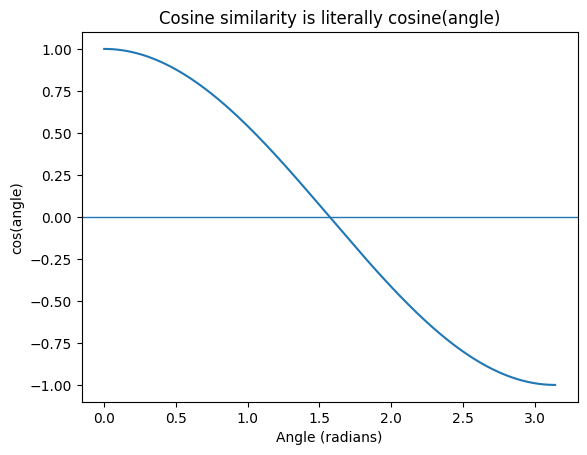

In [6]:
# @title Plot cosine similarity as angle changes
angles = np.linspace(0, np.pi, 200)
cos_vals = np.cos(angles)

plt.figure()
plt.plot(angles, cos_vals)
plt.xlabel("Angle (radians)")
plt.ylabel("cos(angle)")
plt.title("Cosine similarity is literally cosine(angle)")
plt.axhline(0, linewidth=1)
plt.show()


## 🔥 Quick visualization: “similarity matrix”

If we embed a handful of words, we can compute **all pairwise cosine similarities** and visualize them.

**Guiding question:** Which words do you expect to form clusters?


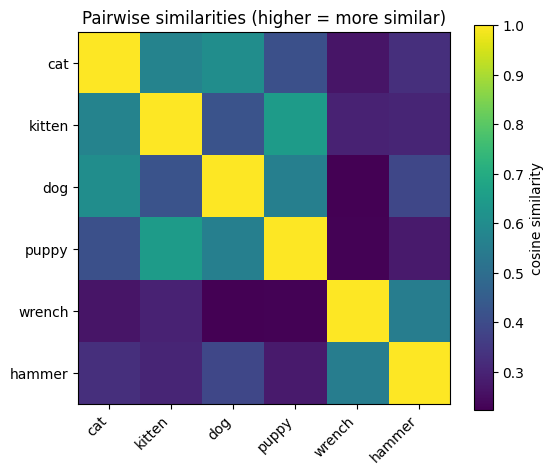

In [12]:
# @title Pairwise cosine similarity heatmap (small set)
terms = ["cat", "kitten", "dog", "puppy", "wrench", "hammer"]
E = np.vstack([get_embedding(t) for t in terms])

S = np.zeros((len(terms), len(terms)), dtype=np.float32)
for i in range(len(terms)):
    for j in range(len(terms)):
        S[i, j] = cosine_similarity(E[i], E[j])

plt.figure(figsize=(6, 5))
plt.imshow(S)
plt.xticks(range(len(terms)), terms, rotation=45, ha="right")
plt.yticks(range(len(terms)), terms)
plt.colorbar(label="cosine similarity")
plt.title("Pairwise similarities (higher = more similar)")
plt.show()


## 🧩 How are embeddings learned? (high level)

We won’t train a big embedding model in this course (it takes massive data + compute), but we *can* understand the idea.

**Core intuition (distributional hypothesis):**
> Words (or texts) that appear in similar contexts tend to have similar meanings.

### A simple training story
During training, the model sees many examples like:

- “The **cat** sat on the ___”  
- “The **kitten** curled up on the ___”

Training encourages embeddings so that:
- “cat” is close to “kitten”
- “cat” is far from unrelated words like “wrench”

A common pattern is **contrastive learning**:  
push *related* things closer, and *unrelated* things farther apart.

### Why this matters for engineers
Because embeddings are learned from data, they can reflect:
- the domain of the data (medical vs sports vs legal)
- biases in the data
- what the training objective rewards

**Reflection:** If you trained embeddings on *only* social media posts, what kinds of “meaning” might they capture well… and what might they miss?


# 🚀 Day 2 — From Similarity to Semantic Systems

Yesterday: vectors + cosine similarity  
Today: using that geometry to build systems.

## **Guiding questions for today**
- **How does semantic search work mathematically?**
- **How do we store and retrieve from an embedding database?**
- **How can we visualize “meaning clusters”?**
- **What does “multimodal” mean, and how can text connect to images?**


## 🔍 What is semantic search?

In keyword search, we match *strings*.  
In semantic search, we match *meaning* using embeddings.

Pipeline:
1. Embed the query: $$\mathbf{q} = \text{embed}(\text{query})$$
2. Embed each document: $$\mathbf{d}_i = \text{embed}(\text{doc}_i)$$
3. Score with cosine similarity: $$s_i = \cos(\mathbf{q}, \mathbf{d}_i)$$
4. Return the top‑$k$ documents by score.

**Important:** This is just a nearest‑neighbors problem in vector space.


In [15]:
# @title Diagram: Semantic search pipeline
diagram = r'''
flowchart LR
  U["User query"] --> E1["Embed query"]
  E1 --> Q["Query vector q"]
  D["Document store"] --> E2["Embed docs"]
  E2 --> V["Vectors d_i"]
  Q --> S["Cosine similarity / dot product"]
  V --> S
  S --> R["Top-k results"]
'''
show_mermaid(diagram)


In [8]:
# @title Build a tiny semantic search function
docs = [
    "A cardiologist specializes in heart conditions.",
    "A dermatologist treats diseases of the skin.",
    "A mechanic repairs car engines and brakes.",
    "Tulane University is located in New Orleans.",
    "Jazz music has deep roots in New Orleans.",
]

# embed each document
# note we do this once, then reuse for each query.
doc_embs = [get_embedding(d) for d in docs]

def semantic_search(query, docs, doc_embs, k=3):
    # embed query
    q = get_embedding(query)
    # compute similarity between each document and the query
    results = []
    for e, d in zip(doc_embs, docs):
      results.append((cosine_similarity(e, q), d))
    # sort results in descending order
    results = sorted(results)[::-1]
    # return top k
    return results[:k]

for score, doc in semantic_search("cardiac doctor", docs, doc_embs, k=3):
    print(f"{score:.3f}  |  {doc}")


0.612  |  A cardiologist specializes in heart conditions.
0.328  |  A dermatologist treats diseases of the skin.
0.197  |  A mechanic repairs car engines and brakes.


In [13]:
list(zip([1,2,3], [4,5,6]))

[(1, 4), (2, 5), (3, 6)]

**Reflection:**  
If we replace cosine similarity with plain dot product, what changes?  
(Hint: dot product is affected by vector length.)


## 📊 Visualizing an “embedding store” (2D map)

We can’t directly *see* 1,536 dimensions. But we can project embeddings down to 2D.

We’ll use a simple method: **PCA** (principal components analysis).  
PCA finds 2 directions that explain as much variation in the data as possible.


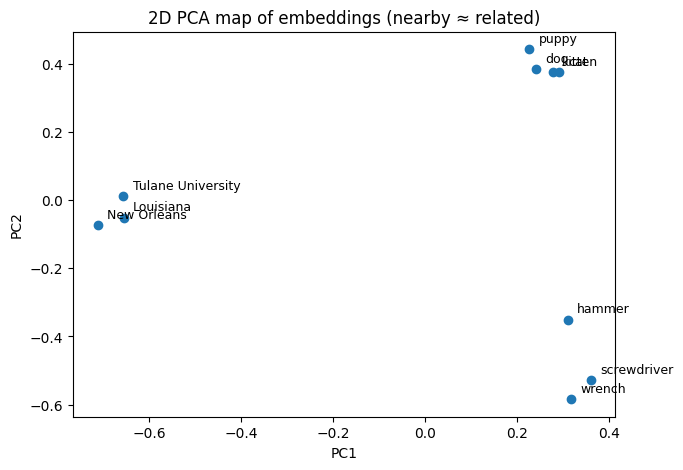

In [9]:
# @title PCA projection + plot (scikit-learn)
from sklearn.decomposition import PCA

texts = [
    "cat", "kitten", "dog", "puppy",
    "wrench", "hammer", "screwdriver",
    "New Orleans", "Louisiana", "Tulane University",
]

# Build the embedding matrix: shape = (num_texts, embedding_dim)
X = [get_embedding(t) for t in texts]

# Reduce embeddings to 2D with PCA
pca = PCA(n_components=2)
pts = pca.fit_transform(X)   # shape = (num_texts, 2)

# plot results
plt.figure(figsize=(7, 5))
plt.scatter(pts[:, 0], pts[:, 1])

for i, label in enumerate(texts):
    plt.text(pts[i, 0] + 0.02,
             pts[i, 1] + 0.02,
             label, fontsize=9)

plt.title("2D PCA map of embeddings (nearby ≈ related)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 🖼️ Multimodal representations (text ↔ images)

**Multimodal** means we represent *different kinds of data* (text, images, audio, …) in a compatible way.

A classic idea (e.g., CLIP-style models) is:
- map images to vectors
- map text to vectors
- train them so matching image↔text pairs are close

### In this notebook (simple version)
We’ll do a lightweight “multimodal bridge”:

1. Use a vision-capable model to write a **one-sentence caption** for an image.
2. Embed that caption with `text-embedding-3-small`.
3. Compare:
   - a text query embedding
   - the caption embedding

This is **not** a true image embedding model — but it demonstrates the system pattern:
> *convert different modalities into a shared representation, then do similarity search.*

**Guiding question:** What information might be lost when we compress an image into a single caption sentence?


In [10]:
# @title Multimodal bridge demo: image -> caption -> embedding
image_url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
text_query = "a dog playing outside"

# 1) Caption the image (vision model)
resp = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "user", "content": [
            {"type": "text", "text": "Describe this image in ONE short sentence."},
            {"type": "image_url", "image_url": {"url": image_url}}
        ]}
    ],
)
caption = resp.choices[0].message.content.strip()
print("Caption:", caption)

# 2) Embed caption and compare to the text query
cap_emb = get_embedding(caption)
q_emb = get_embedding(text_query)

print("Cosine similarity(query, caption):", cosine_similarity(q_emb, cap_emb))


Caption: A fluffy golden retriever puppy rests its paws on a mossy log in a green outdoor setting.
Cosine similarity(query, caption): 0.4867233633995056


## 🧩 Wrap‑up: what we can do now

By turning text into vectors, we can:
- compare meaning with **cosine similarity**
- build **semantic search** systems
- visualize clusters and reason about “concept neighborhoods”
- extend the idea to **multimodal pipelines**

### Next week’s lab (preview)
You’ll build a small system that uses embeddings for **retrieval** (and then uses an LLM to answer based on retrieved context).

**In-class activity (10–15 min):**
- Sketch a pipeline for a “helpful course assistant.”
- Where would embeddings go?
- Where could it fail? How would you test it?


## 🧠 Concept Check (answer in your own words)

1. What is an **embedding**?  
2. In one sentence: what does **cosine similarity** measure?  
3. Why might cosine similarity be preferable to Euclidean distance for text embeddings?  
4. Write the semantic search scoring rule in symbols: how do we compute a score for doc $i$?  
5. What is one common **failure mode** of embeddings in real systems?  
6. What does PCA help us do in the notebook?  
7. In the “multimodal bridge” demo, what *two steps* connected images to text embeddings?  
8. If your semantic search returns bad results, name **one thing** you could try (data, prompt, chunking, model choice, etc.).

<details>
<summary><b>Show suggested answers</b></summary>

1. An embedding is a vector of numbers that places an item (like text) in a space where geometry corresponds to meaning.  
2. It measures the angle between two vectors (how aligned their directions are).  
3. It focuses on direction (meaning) and is less sensitive to vector magnitude.  
4. $s_i = \cos(\mathbf{q}, \mathbf{d}_i)$ where $\mathbf{q}$ is the query embedding and $\mathbf{d}_i$ is document $i$’s embedding.  
5. Ambiguity (polysemy), negation, domain mismatch, or bias from training data.  
6. It projects high‑dimensional embeddings down to 2D so we can visualize structure/clusters.  
7. (1) Vision model generated a caption, (2) we embedded the caption and compared it to a text query.  
8. Examples: improve documents/chunks, add metadata filters, change embedding model, adjust similarity metric, add reranking, evaluate with a test set.

</details>


<details>
<summary><b>Instructor Notes</b></summary>

### Suggested pacing (two 75-minute sessions)

**Day 1 (75 min)**
- (10m) Lab recap + “meaning vs keywords” discussion
- (10m) Motivating example: keyword vs semantic search demo
- (15m) What embeddings are + vector crash course
- (20m) Cosine similarity: formula + tiny vector demo + embedding pairs
- (15m) Similarity heatmap + reflection on failure modes
- (5m) Exit ticket: “Where would embeddings fit in a system you’ve used?”

**Day 2 (75 min)**
- (10m) Recap + guiding questions
- (20m) Semantic search math + tiny search function demo
- (20m) PCA visualization + interpretation (clusters, neighbors)
- (15m) Multimodal bridge demo + discussion of what’s lost in captions
- (10m) Preview next lab + concept check

### Discussion transitions / prompts
- After the motivating example: “Why is this *hard* for keywords but *natural* for geometry?”
- After cosine formula: “What does it mean for two meanings to point in the same direction?”
- After semantic search: “Where could this go wrong in a real product?”
- After PCA plot: “Which neighbors look reasonable? Which look weird?”

### Optional extension (if time)
- Add a small “evaluation set” of 10 queries and compute top‑1 accuracy.
- Compare cosine similarity vs dot product by artificially scaling a vector.

</details>
